# HLS × ECOSTRESS Fused Time Series — West Lafayette, Indiana

Builds a **gap-free, ROI-clipped, evenly-spaced fused image cube** from optical
(HLS NDVI) and thermal (ECOSTRESS ET) data, verifies it visually, and archives
it to the CyVerse Data Store.

### Design rules this notebook follows

**Every cell persists its result to disk, and the next cell loads it from disk.**
You can restart the kernel and run any cell on its own. No cell depends on a
variable that only exists in memory from an earlier run.

**Reference grids are derived from the ROI, never from whichever scene arrives
first.** An earlier version took the grid from the first downloaded granule; when
that granule covered only part of the ROI, every later scene was silently
resampled down to that partial footprint and 46% of the study area was lost with
no error message.

**Per-scene cache stores coordinates, not bare arrays.** NetCDF keeps the CRS and
the x/y axes, so the grid can be changed later without re-downloading anything.

### Products written

| File | Contents |
|---|---|
| `roi.geojson`, `windows.csv` | study area and 16-day window definitions |
| `grid_30m.nc`, `grid_70m.nc` | reference grids, both spanning the full ROI |
| `cache/hls/*.nc`, `cache/eco/*.nc` | one file per scene, resumable |
| `ndvi_scenes.nc`, `et_scenes.nc` | per-scene stacks, cloud/QC masked |
| `fused_cube.nc` | **the deliverable** — NDVI + ET on one 16-day axis |
| `cdl.tif` | cropland mask clipped to the ROI |


In [1]:
# =============================================================================
# Cell 1 — Imports and configuration
# =============================================================================
# Every tunable value lives here. Nothing downstream hard-codes a path or a date.
import os, re, json, time, gc, shutil, zipfile
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
from shapely.geometry import box
from rasterio.enums import Resampling
import earthaccess
import warnings; warnings.filterwarnings("ignore")

CFG = dict(
    # --- study area ------------------------------------------------------
    center   = (-86.9950, 40.4820),      # lon, lat — near Purdue ACRE farm
    half_km  = 5.0,                      # half-width → 10 x 10 km square
    region   = "westlafayette",

    # --- time ------------------------------------------------------------
    date_start  = "2024-09-01",          # after the 2024 harvest
    date_end    = "2025-10-31",          # through the 2025 growing season
    x_days      = 16,                    # fused time-step length
    offseason   = ("2024-11-01", "2025-05-31"),
    termination = ("2025-03-15", "2025-06-15"),

    # --- resolution ------------------------------------------------------
    res_optical = 30,                    # HLS native
    res_thermal = 70,                    # ECOSTRESS native

    # --- products / masking ----------------------------------------------
    eco_product = "ECO_L3T_JET",         # daily ET — overpass time already handled
    eco_var     = "ET",
    cloud_max   = 80.0,                  # loose scene pre-filter; Fmask does the work
    utc_offset  = -5,                    # Indiana ≈ UTC-5
    crop_codes  = [1, 5],                # CDL: 1 corn, 5 soybeans

    # --- storage ---------------------------------------------------------
    # The working directory MUST sit on the container's local disk. The Data
    # Store (/home/jovyan/data-store/...) is an iRODS FUSE mount: it accepts
    # os.makedirs and then rejects the random-access writes netCDF4 needs,
    # raising a bare PermissionError. Finished products are copied there by
    # the archive cell at the end.
    work      = "/home/jovyan/fusion_work",
    cdl_zip   = "/data-store/iplant/home/pengyuwh/CDL_10m/2025_10m_cdls.zip",
    cdl_year  = 2025,
    archive   = "/data-store/iplant/home/pengyuwh/CoverCrop_Fusion",  # Data Store
)

# Derived paths — created here so no later cell has to worry about them.
WORK      = os.path.abspath(CFG["work"])
CACHE_HLS = os.path.join(WORK, "cache", "hls")
CACHE_ECO = os.path.join(WORK, "cache", "eco")
FIG_DIR   = os.path.join(WORK, "figures")
for d in (WORK, CACHE_HLS, CACHE_ECO, FIG_DIR):
    os.makedirs(d, exist_ok=True)

P = lambda name: os.path.join(WORK, name)      # shorthand for a working-dir path

def load_da(path, name=None):
    """Open a NetCDF written by this notebook and return it as a DataArray.

    rioxarray's write_crs() stores the projection as a companion `spatial_ref`
    variable, so the saved file holds two data variables and a plain DataArray
    reader refuses to guess which one is wanted. Naming the variable explicitly
    removes the ambiguity; when `name` is omitted the one non-projection
    variable is selected.
    """
    ds = xr.open_dataset(path)
    if name is None:
        name = next(v for v in ds.data_vars if v != "spatial_ref")
    da = ds[name]
    if da.rio.crs is None and "spatial_ref" in ds:
        # to_netcdf demotes the projection to a plain variable, and a silently
        # CRS-less array reprojects to the wrong place rather than raising.
        att = ds["spatial_ref"].attrs
        wkt = att.get("crs_wkt") or att.get("spatial_ref")
        if wkt:
            da = da.rio.write_crs(wkt)
    return da


print(f"working dir : {WORK}")
print(f"archive dest: {CFG['archive']}")
print(f"period      : {CFG['date_start']} → {CFG['date_end']}  "
      f"({CFG['x_days']}-day steps)")

# Prove the working directory really accepts a NetCDF write. A FUSE-mounted
# path passes os.makedirs and only fails many cells later, so test it here.
_probe = P(".write_test.nc")
xr.DataArray(np.zeros((2, 2), "float32"), dims=("y", "x")).to_netcdf(_probe)
os.remove(_probe)
print("NetCDF write test: OK")

working dir : /home/jovyan/fusion_work
archive dest: /data-store/iplant/home/pengyuwh/CoverCrop_Fusion
period      : 2024-09-01 → 2025-10-31  (16-day steps)
NetCDF write test: OK


## Cell 2 — Earthdata authentication

A free account is required: <https://urs.earthdata.nasa.gov/>. `persist=True`
writes credentials to `~/.netrc` on first use, so later runs need no input.
Never put a password in a notebook.

In [2]:
# =============================================================================
# Cell 2 — Authenticate
# =============================================================================
auth = earthaccess.login(persist=True)
assert auth.authenticated, "Earthdata login failed — check ~/.netrc"
print("Earthdata: authenticated")

Earthdata: authenticated


## Cell 3 — Study area and time windows

Two subtleties, both of which fail silently rather than raising:

**Longitude degrees shrink with latitude.** The half-width in degrees must be
divided by `cos(lat)`, or a "10 km box" comes out as a 10 × 13 km rectangle. The
assertion below measures the result in a projected CRS and refuses anything that
isn't square.

**Windows are half-open** `[start, next)`. Scene timestamps carry hours and
minutes; with closed intervals ending at midnight, every observation later than
00:00 on a window's final day falls between two windows and is dropped — roughly
one day in every sixteen.

Outputs `roi.geojson` and `windows.csv`; every later cell reads those files.

In [3]:
# =============================================================================
# Cell 3 — Define the ROI and the 16-day windows, then save them
# =============================================================================
lon, lat, half = *CFG["center"], CFG["half_km"]

# Longitude degrees shrink with latitude — divide by cos(lat) or the box skews.
dlat = half / 111.32
dlon = half / (111.32 * np.cos(np.radians(lat)))
bbox = (lon - dlon, lat - dlat, lon + dlon, lat + dlat)
assert bbox[0] < bbox[2] and bbox[1] < bbox[3], "bbox corners are swapped"

roi = gpd.GeoDataFrame({"name": [CFG["region"]]},
                       geometry=[box(*bbox)], crs="EPSG:4326")
roi.to_file(P("roi.geojson"), driver="GeoJSON")

# Confirm squareness where distances are metric, not in degrees
utm = roi.estimate_utm_crs()
x0, y0, x1, y1 = roi.to_crs(utm).total_bounds
w_km, h_km = (x1 - x0) / 1000, (y1 - y0) / 1000
assert 0.98 < w_km / h_km < 1.02, f"ROI is not square: ratio {w_km/h_km:.3f}"


def make_windows(start, end, x_days):
    """Split [start, end] into consecutive HALF-OPEN x-day windows.

    Returns win_id / win_start / win_next (exclusive) / win_end (inclusive,
    for file naming) / win_center.
    """
    start, end = pd.Timestamp(start), pd.Timestamp(end)
    end_excl = end + pd.Timedelta(days=1)          # include all of the last day
    edges = pd.date_range(start, end_excl + pd.Timedelta(days=x_days),
                          freq=f"{x_days}D")
    rows = []
    for i, e in enumerate(edges[:-1]):
        if e >= end_excl:
            break
        nxt = min(edges[i + 1], end_excl)
        rows.append(dict(win_id=i, win_start=e, win_next=nxt,
                         win_end=nxt - pd.Timedelta(days=1),
                         win_center=e + (nxt - e) / 2))
    w = pd.DataFrame(rows)
    assert (w.win_next.values[:-1] == w.win_start.values[1:]).all(), \
        "windows must tile with no gap and no overlap"
    return w


windows = make_windows(CFG["date_start"], CFG["date_end"], CFG["x_days"])
windows.to_csv(P("windows.csv"), index=False)

print(f"ROI      : {w_km:.2f} x {h_km:.2f} km   ({utm.name})")
print(f"bbox     : {tuple(round(v, 4) for v in bbox)}")
print(f"windows  : {len(windows)} x {CFG['x_days']} days")
print(f"saved    : roi.geojson, windows.csv")
windows.head(3)

ROI      : 10.02 x 9.97 km   (WGS 84 / UTM zone 16N)
bbox     : (np.float64(-87.0541), 40.4371, np.float64(-86.9359), 40.5269)
windows  : 27 x 16 days
saved    : roi.geojson, windows.csv


,win_id,win_start,win_next,win_end,win_center
0,0,2024-09-01,2024-09-17,2024-09-16,2024-09-09
1,1,2024-09-17,2024-10-03,2024-10-02,2024-09-25
2,2,2024-10-03,2024-10-19,2024-10-18,2024-10-11


## Cell 4 — Reference grids

**This is where the earlier version went wrong.** It let the first downloaded
granule define the grid. That granule covered only the eastern half of the ROI,
so the grid was 5.5 km wide instead of 10 km, and every later scene — including
ones with complete coverage — was resampled down onto it. The western 46% of the
study area vanished, with no error and no warning; it only surfaced much later as
"0 valid samples".

Both grids are now built from the ROI polygon itself and share one CRS and one
origin, so the 30 m and 70 m products stay registered to each other.

In [4]:
# =============================================================================
# Cell 4 — Build the 30 m and 70 m reference grids from the ROI
# =============================================================================
roi = gpd.read_file(P("roi.geojson"))            # reload: cell stands alone
utm = roi.estimate_utm_crs()


def make_grid(roi, res, crs):
    """An empty raster spanning the ROI at `res` metres.

    Derived from the ROI, never from a scene — a scene-derived grid inherits
    that scene's footprint and silently truncates everything else.
    """
    x0, y0, x1, y1 = roi.to_crs(crs).total_bounds
    nx, ny = int(np.ceil((x1 - x0) / res)), int(np.ceil((y1 - y0) / res))
    return xr.DataArray(
        np.full((ny, nx), np.nan, "float32"),
        coords={"y": y1 - (np.arange(ny) + 0.5) * res,
                "x": x0 + (np.arange(nx) + 0.5) * res},
        dims=("y", "x"), name="grid").rio.write_crs(crs)


grid30 = make_grid(roi, CFG["res_optical"], utm)
grid70 = make_grid(roi, CFG["res_thermal"], utm)
grid30.to_netcdf(P("grid_30m.nc"))
grid70.to_netcdf(P("grid_70m.nc"))

# Both grids must cover the ROI, not merely overlap it
rx0, ry0, rx1, ry1 = roi.to_crs(utm).total_bounds
for g, res in ((grid30, CFG["res_optical"]), (grid70, CFG["res_thermal"])):
    span_x, span_y = g.sizes["x"] * res, g.sizes["y"] * res
    assert span_x >= (rx1 - rx0) and span_y >= (ry1 - ry0), \
        f"{res} m grid is smaller than the ROI"
    print(f"{res:>3} m grid: {g.sizes['y']:>4} x {g.sizes['x']:<4} px  "
          f"= {span_y/1000:.2f} x {span_x/1000:.2f} km")

print(f"\nCRS: {utm.name}")
print("saved: grid_30m.nc, grid_70m.nc")

 30 m grid:  333 x 334  px  = 9.99 x 10.02 km
 70 m grid:  143 x 144  px  = 10.01 x 10.08 km

CRS: WGS 84 / UTM zone 16N
saved: grid_30m.nc, grid_70m.nc


## Cell 5 — Find HLS scenes

`HLSL30` (Landsat 8/9) and `HLSS30` (Sentinel-2 A/B) are already harmonised by
NASA — one 30 m grid, one atmospheric correction, BRDF-normalised, with
Sentinel-2 bands adjusted to Landsat band-passes. Combining them into a single
series is the entire purpose of the product.

Two details that fail without an error message:

- **`HLSF30` does not exist.** CMR ignores an unknown short name, halving your
  temporal density while appearing to succeed.
- **NIR differs by sensor**: Landsat `B05`, Sentinel-2 **`B8A`** (narrow NIR,
  865 nm) — *not* `B08`. NASA harmonised against B8A; B08 introduces a bias.

Scene cloud cover lives in `AdditionalAttributes.CLOUD_COVERAGE`, not in the
standard UMM `CloudCover` field. Missing metadata is treated as 0% (keep the
scene) — per-pixel Fmask does the real masking, so an unreadable field must not
throw away a usable observation.

In [5]:
# =============================================================================
# Cell 5 — Search HLS, resolve band URLs, save the index
# =============================================================================
roi = gpd.read_file(P("roi.geojson"))
bbox = tuple(roi.total_bounds)

HLS_BANDS = {"L30": {"red": "B04", "nir": "B05"},    # Landsat 8/9
             "S30": {"red": "B04", "nir": "B8A"}}    # Sentinel-2: B8A, not B08

granules = earthaccess.search_data(
    short_name=["HLSL30", "HLSS30"],   # HLSF30 is not a real product
    bounding_box=bbox,
    temporal=(CFG["date_start"], CFG["date_end"]),
    count=-1)                          # -1 = all; a fixed count truncates
assert granules, "no HLS granules found — check bbox, dates, login"

rows = []
for g in granules:
    parts = g["meta"]["native-id"].split(".")     # HLS.S30.T16TDK.2024274T16...
    sensor, tile = parts[1], parts[2]
    attrs = {a.get("Name", ""): a.get("Values", [None])[0]
             for a in g["umm"].get("AdditionalAttributes", [])}
    try:
        cloud = float(attrs.get("CLOUD_COVERAGE"))
    except (TypeError, ValueError):
        cloud = np.nan                            # unknown ≠ cloudy
    if np.nan_to_num(cloud, nan=0.0) > CFG["cloud_max"]:
        continue

    links = g.data_links()
    pick = lambda s: next((l for l in links if l.endswith(f".{s}.tif")), None)
    red, nir, fmask = (pick(HLS_BANDS[sensor]["red"]),
                       pick(HLS_BANDS[sensor]["nir"]), pick("Fmask"))
    if not (red and nir and fmask):
        continue
    rows.append(dict(gid=g["meta"]["native-id"], sensor=sensor, tile=tile,
                     date=pd.to_datetime(parts[3][:7], format="%Y%j"),
                     cloud=cloud, red=red, nir=nir, fmask=fmask))

hls_index = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
assert len(hls_index), "no granule had a complete red/NIR/Fmask set"
hls_index.to_csv(P("hls_index.csv"), index=False)

print(f"granules found : {len(granules)}  →  usable {len(hls_index)}")
print(f"sensors        : {dict(hls_index.sensor.value_counts())}")
print(f"MGRS tiles     : {dict(hls_index.tile.value_counts())}  "
      f"← mosaicked onto one grid")
print(f"dates          : {hls_index.date.min().date()} → {hls_index.date.max().date()}")
print(f"saved          : hls_index.csv")

granules found : 363  →  usable 273
sensors        : {'S30': np.int64(214), 'L30': np.int64(59)}
MGRS tiles     : {'T16TDK': np.int64(142), 'T16TEK': np.int64(131)}  ← mosaicked onto one grid
dates          : 2024-09-03 → 2025-10-31
saved          : hls_index.csv


## Cell 6 — Download HLS and compute NDVI

**Fmask bits (HLS v2.0):** 0 cirrus · 1 cloud · 2 adjacent to cloud · 3 cloud
shadow · 4 snow/ice · 5 water · 6–7 aerosol level.

Bits 0–5 are masked; bits 6–7 are deliberately left alone — masking the aerosol
level discards a great many good observations. Snow (bit 4) matters here:
unmasked winter snow reads as low NDVI and imitates bare soil.

Each scene is saved as NetCDF **with its coordinates**, so the grid can be
changed later without re-downloading. NDVI is a ratio, so reflectance scale
factors cancel — no scaling needed.

*Slowest cell: roughly 4 s per scene. Safe to interrupt; re-running skips
whatever is already cached.*

In [6]:
# =============================================================================
# Cell 6 — Download each scene, compute NDVI, cache as NetCDF (resumable)
# =============================================================================
hls_index = pd.read_csv(P("hls_index.csv"), parse_dates=["date"])
grid30 = load_da(P("grid_30m.nc")).rio.write_crs(
    gpd.read_file(P("roi.geojson")).estimate_utm_crs())
roi = gpd.read_file(P("roi.geojson"))

# bits 0-5 = cirrus, cloud, adjacent, shadow, snow, water. 6-7 = aerosol: keep.
FMASK_BAD = sum(1 << b for b in range(6))         # 0b00111111 = 63
assert (64 & FMASK_BAD) == 0 and (128 & FMASK_BAD) == 0, "aerosol bits masked!"


def open_clip(handle, roi, masked=True):
    """Open a remote GeoTIFF and clip it to the ROI in its own CRS."""
    da = rxr.open_rasterio(handle, masked=masked).squeeze(drop=True)
    return da.rio.clip(roi.to_crs(da.rio.crs).geometry, from_disk=True)


def download_hls(index, cache_dir, grid, roi, max_retry=3):
    """Fetch red/NIR/Fmask, compute NDVI, put it on `grid`, cache as NetCDF."""
    t0, new, hit, failed = time.time(), 0, 0, []

    for i, r in index.iterrows():
        path = os.path.join(cache_dir, r.gid + ".nc")   # granule id = unique
        if os.path.exists(path):
            hit += 1
            continue

        err = None
        for attempt in range(max_retry):
            handles = None
            try:
                handles = earthaccess.open([r.red, r.nir, r.fmask])
                red, nir = open_clip(handles[0], roi), open_clip(handles[1], roi)
                fmask = open_clip(handles[2], roi, masked=False)

                ndvi = (nir - red) / (nir + red)
                ndvi = ndvi.where((ndvi >= -1) & (ndvi <= 1))   # physical range

                # Always reproject onto the reference grid. Comparing shapes
                # alone is unsafe: two MGRS tiles can clip to identical shapes
                # with different origins, and that misalignment is invisible
                # once the array is stored.
                ndvi  = ndvi.rio.reproject_match(grid)
                fmask = fmask.rio.reproject_match(grid)

                clear = (np.nan_to_num(fmask.values, nan=255).astype("uint8")
                         & FMASK_BAD) == 0
                masked = ndvi.where(xr.DataArray(clear, coords=ndvi.coords,
                                                 dims=ndvi.dims))
                masked.name = "ndvi"
                # Replace the inherited attributes, do not extend them. HLS
                # reflectance carries scale_factor=0.0001; NDVI is a ratio and
                # already unitless, but the attribute rides along and xarray
                # re-applies it on the next read, shrinking every value by 1e4
                # with no warning. Clearing encoding stops the same values
                # from being written back as packed integers.
                masked.attrs = dict(gid=r.gid, sensor=r.sensor,
                                    date=str(r.date.date()))
                masked.encoding = {}
                masked.to_netcdf(path)
                new, err = new + 1, None
                break
            except Exception as e:
                err = f"{type(e).__name__}: {e}"
                time.sleep(5 * 2 ** attempt)              # exponential back-off
            finally:
                for h in handles or []:
                    try: h.close()
                    except Exception: pass

        if err:
            failed.append(dict(gid=r.gid, error=err[:80]))
        if new == 3:                                       # measured, not guessed
            per = (time.time() - t0) / 3
            print(f"[measured] {per:.1f}s/scene → "
                  f"~{per*(len(index)-hit-new)/60:.0f} min remaining")
        if new and new % 25 == 0:
            print(f"  {i+1}/{len(index)}  downloaded {new}  "
                  f"({(time.time()-t0)/60:.1f} min)")
        gc.collect()

    print(f"\nHLS: {new} new, {hit} cached, {len(failed)} failed "
          f"({(time.time()-t0)/60:.1f} min)")
    if failed:
        print(pd.DataFrame(failed).to_string(index=False))
        print("Re-run this cell to retry only the failures.")
    return failed


hls_failed = download_hls(hls_index, CACHE_HLS, grid30, roi)
n_cached = len([f for f in os.listdir(CACHE_HLS) if f.endswith(".nc")])
print(f"cache now holds {n_cached} / {len(hls_index)} scenes")


HLS: 0 new, 273 cached, 0 failed (0.0 min)
cache now holds 273 / 273 scenes


## Cell 7 — Stack the scenes into one NDVI cube

Loads every cached scene, drops any that are entirely cloud-masked, merges
same-day observations (Landsat and Sentinel-2 sometimes pass on the same day),
and writes `ndvi_scenes.nc`.

The printed per-scene valid fraction is the first place a coverage problem shows
up. Every scene should be close to 100%; a scene stuck near 50% means the grid
and the data disagree.

In [7]:
# =============================================================================
# Cell 7 — Assemble the per-scene NDVI stack
# =============================================================================
files = sorted(f for f in os.listdir(CACHE_HLS) if f.endswith(".nc"))
assert files, "HLS cache is empty — run Cell 6 first"

arrays, dates, sensors, fracs = [], [], [], []
for fn in files:
    da = load_da(os.path.join(CACHE_HLS, fn))
    frac = float(np.isfinite(da.values).mean())
    if frac == 0:                       # scene entirely clouded out
        continue
    arrays.append(da.values.astype("float32"))
    dates.append(pd.to_datetime(fn.split(".")[3][:7], format="%Y%j"))
    sensors.append(fn.split(".")[1])
    fracs.append(frac)
    da.close()

grid30 = load_da(P("grid_30m.nc"))
ndvi = xr.DataArray(np.stack(arrays), dims=("time", "y", "x"),
                    coords={"time": pd.DatetimeIndex(dates),
                            "y": grid30.y, "x": grid30.x}, name="ndvi")

# Same-day L30 + S30 overpasses are averaged so neither is counted twice
n_before = ndvi.sizes["time"]
ndvi = ndvi.groupby("time").mean("time").sortby("time")
ndvi.to_netcdf(P("ndvi_scenes.nc"))

fr = np.array(fracs)
print(f"scenes loaded    : {len(files)}  →  usable {len(arrays)}")
print(f"same-day merged  : {n_before - ndvi.sizes['time']}")
print(f"observation days : {ndvi.sizes['time']}")
print(f"grid             : {ndvi.sizes['y']} x {ndvi.sizes['x']} px")
print(f"\nper-scene valid fraction (after cloud masking):")
print(f"  median {np.median(fr):.1%} | >90%: {(fr>0.9).sum()} | "
      f"50-90%: {((fr>0.5)&(fr<=0.9)).sum()} | <50%: {(fr<=0.5).sum()}")
print(f"  → scenes clustered near one value below 100% would mean the grid "
      f"and the data disagree")
print(f"\nsaved: ndvi_scenes.nc")

scenes loaded    : 273  →  usable 247
same-day merged  : 131
observation days : 116
grid             : 333 x 334 px

per-scene valid fraction (after cloud masking):
  median 49.0% | >90%: 49 | 50-90%: 68 | <50%: 130
  → scenes clustered near one value below 100% would mean the grid and the data disagree

saved: ndvi_scenes.nc


## Cell 8 — Find ECOSTRESS scenes

`ECO_L3T_JET` is a **daily-integrated** evapotranspiration product, which matters
because ECOSTRESS flies on the ISS in a non-sun-synchronous orbit — it passes at
08:00 one day and 15:00 the next. An instantaneous variable such as LST would
need overpass-time normalisation before values from different days could be
compared; daily ET has that handled upstream.

ET is the physically meaningful signal here: when a cover crop is terminated,
transpiration stops within days while the canopy stays green for one to two
weeks. That lag is what optical data alone cannot see.

In [8]:
# =============================================================================
# Cell 8 — Search ECOSTRESS and save the index
# =============================================================================
roi = gpd.read_file(P("roi.geojson"))
bbox = tuple(roi.total_bounds)

# Layer-file patterns inside each granule, in priority order
ECO_PATTERNS = {"ET":  [r"ETdaily\.tif$", r"ETinst\.tif$", r"_ET\.tif$"],
                "LST": [r"_LST\.tif$"]}
ECO_QC = [r"_cloud\.tif$", r"_QC\.tif$"]

granules = earthaccess.search_data(
    short_name=CFG["eco_product"], bounding_box=bbox,
    temporal=(CFG["date_start"], CFG["date_end"]), count=-1)
assert granules, f"no {CFG['eco_product']} granules found"

rows = []
for g in granules:
    links = g.data_links()
    var_url = next((l for p in ECO_PATTERNS[CFG["eco_var"]]
                    for l in links if re.search(p, l)), None)
    if not var_url:
        continue
    qc_url = next((l for p in ECO_QC for l in links if re.search(p, l)), None)
    try:
        t = pd.to_datetime(g["umm"]["TemporalExtent"]["RangeDateTime"]
                           ["BeginningDateTime"]).tz_localize(None)
    except Exception:
        continue
    rows.append(dict(gid=g["meta"]["native-id"],
                     local=t + pd.Timedelta(hours=CFG["utc_offset"]),
                     var=var_url, qc=qc_url))

eco_index = pd.DataFrame(rows).sort_values("local").reset_index(drop=True)
assert len(eco_index), f"no {CFG['eco_var']} band file inside these granules"
eco_index["hour"] = eco_index.local.dt.hour + eco_index.local.dt.minute / 60
eco_index.to_csv(P("eco_index.csv"), index=False)

day = eco_index[(eco_index.hour >= 7) & (eco_index.hour <= 19)]
print(f"{CFG['eco_product']} / {CFG['eco_var']}")
print(f"  granules       : {len(eco_index)}   (daytime {len(day)})")
print(f"  overpass hours : {eco_index.hour.min():.1f} – {eco_index.hour.max():.1f} local")
print(f"  dates          : {eco_index.local.min().date()} → {eco_index.local.max().date()}")
print(f"  with QC layer  : {eco_index['qc'].notna().sum()}")
print(f"  saved          : eco_index.csv")

ECO_L3T_JET / ET
  granules       : 217   (daytime 211)
  overpass hours : 6.2 – 19.0 local
  dates          : 2024-10-06 → 2025-10-28
  with QC layer  : 217
  saved          : eco_index.csv


## Cell 9 — Download ECOSTRESS

Same pattern as the HLS download: NetCDF per granule with coordinates, resumable,
**always** reprojected onto the 70 m reference grid built in Cell 4.

The reference grid is the whole point of this cell. Handing ECOSTRESS its own
scene-derived grid is exactly what truncated the study area last time.

QC masking is deliberately conservative — any non-zero flag discards the pixel.
The printed valid-fraction histogram is the check: a granule that genuinely
covers the ROI should read near 100%, and a cluster of scenes pinned at some
intermediate value means the grid and the data are not aligned.

In [9]:
# =============================================================================
# Cell 9 — Download ECOSTRESS onto the reference grid (resumable)
# =============================================================================
eco_index = pd.read_csv(P("eco_index.csv"), parse_dates=["local"])
roi = gpd.read_file(P("roi.geojson"))
grid70 = load_da(P("grid_70m.nc")).rio.write_crs(roi.estimate_utm_crs())


def download_eco(index, cache_dir, grid, roi, var, max_retry=3):
    """Fetch one ECOSTRESS variable, QC-mask it, put it on `grid`, cache it."""
    t0, new, hit, failed = time.time(), 0, 0, 0

    for i, r in index.iterrows():
        path = os.path.join(cache_dir, f"{var}_{r.gid}.nc")
        if os.path.exists(path):
            hit += 1
            continue

        ok = False
        for attempt in range(max_retry):
            handles = None
            try:
                urls = [r["var"]] + ([r.qc] if isinstance(r.qc, str) else [])
                handles = earthaccess.open(urls)
                val = open_clip(handles[0], roi)

                # Unconditional reprojection onto the ROI-derived grid.
                # Matching on shape alone would let a differently-originated
                # tile through, and the misalignment is invisible afterwards.
                val = val.rio.reproject_match(grid)

                if len(handles) > 1:
                    qc = open_clip(handles[1], roi, masked=False)
                    qc = qc.rio.reproject_match(grid)
                    bad = np.nan_to_num(qc.values, nan=1) > 0
                    val = val.where(~xr.DataArray(bad, coords=val.coords,
                                                  dims=val.dims))

                val.name = var
                # Same hygiene as the HLS cache: an inherited scale_factor /
                # add_offset would be re-applied on the next read.
                val.attrs = dict(gid=r.gid, local_time=str(r.local))
                val.encoding = {}
                val.to_netcdf(path)
                new, ok = new + 1, True
                break
            except Exception:
                time.sleep(5 * 2 ** attempt)
            finally:
                for h in handles or []:
                    try: h.close()
                    except Exception: pass
        if not ok:
            failed += 1
        if new and new % 25 == 0:
            print(f"  {i+1}/{len(index)}  downloaded {new}  "
                  f"({(time.time()-t0)/60:.1f} min)")
        gc.collect()

    print(f"\n{var}: {new} new, {hit} cached, {failed} failed "
          f"({(time.time()-t0)/60:.1f} min)")


download_eco(eco_index, CACHE_ECO, grid70, roi, CFG["eco_var"])

# Verify coverage: this is the check that would have caught the truncated grid
fr = []
for fn in sorted(os.listdir(CACHE_ECO))[:60]:
    if not fn.endswith(".nc"):
        continue
    da = load_da(os.path.join(CACHE_ECO, fn))
    fr.append(float(np.isfinite(da.values).mean())); da.close()
fr = np.array(fr)
print(f"\ncached granules sampled: {len(fr)}")
print(f"  empty (<1%)     : {(fr < 0.01).sum()}")
print(f"  partial (1-95%) : {((fr >= 0.01) & (fr < 0.95)).sum()}")
print(f"  near-full (>95%): {(fr >= 0.95).sum()}")
print(f"  best coverage   : {fr.max():.1%}  ← must approach 100%, "
      f"otherwise grid and data disagree")


ET: 0 new, 217 cached, 0 failed (0.0 min)

cached granules sampled: 60
  empty (<1%)     : 34
  partial (1-95%) : 17
  near-full (>95%): 9
  best coverage   : 98.6%  ← must approach 100%, otherwise grid and data disagree


## Cell 10 — Fuse into an evenly-spaced cube

Two variables, one 16-day axis:

- **NDVI → median.** Thin cloud that Fmask missed biases values *upward*; the
  median resists a few contaminated observations, the mean does not.
- **ET → mean.** Already sparse; a median over one or two observations gains
  nothing and discards information.

**Then gaps are filled by linear interpolation along time.** Cloudy winter
windows can leave a layer almost empty — one window in the earlier run was 0.2%
valid — and any downstream consumer that requires complete layers is destroyed by
a single such window. Interpolation leaves observed values untouched; the
printed interpolated fraction says how much of the cube is inferred rather than
measured, and should be read alongside any result.

ET stays on its native 70 m grid. Resampling it to 30 m here would add an
interpolation without adding information.

In [10]:
# =============================================================================
# Cell 10 — Composite to 16-day windows, fill temporal gaps, save the cube
# =============================================================================
windows = pd.read_csv(P("windows.csv"), parse_dates=["win_start", "win_next",
                                                     "win_end", "win_center"])
ndvi_scenes = load_da(P("ndvi_scenes.nc"))


def assign_windows(times, windows):
    """Map observation times to window ids; -1 = outside every window.
    Half-open [win_start, win_next) so nothing falls between two windows."""
    t = pd.DatetimeIndex(times)
    out = np.full(len(t), -1, dtype=int)
    for _, w in windows.iterrows():
        out[(t >= w.win_start) & (t < w.win_next)] = w.win_id
    return out


def composite(values, win_idx, n_win, how):
    """Aggregate (n_obs, y, x) into (n_win, y, x). Empty windows stay NaN."""
    fn = {"median": np.nanmedian, "mean": np.nanmean}[how]
    out = np.full((n_win,) + values.shape[1:], np.nan, "float32")
    for w in range(n_win):
        sel = np.where(win_idx == w)[0]
        if len(sel):
            with np.errstate(all="ignore"):
                out[w] = fn(values[sel], axis=0)
    return out


def fill_time_gaps(cube, label):
    """Linear interpolation along the time axis, per pixel.
    Observed values are never modified — only NaNs are filled."""
    n = cube.shape[0]
    before = np.isfinite(cube).mean()
    filled = (pd.DataFrame(cube.reshape(n, -1))
                .interpolate(axis=0, limit_direction="both")
                .values.reshape(cube.shape).astype("float32"))
    observed = np.isfinite(cube)
    assert np.allclose(filled[observed], cube[observed]), \
        "interpolation altered an observed value"
    print(f"  {label:<5} valid {before:.1%} → {np.isfinite(filled).mean():.1%} "
          f"(interpolated {np.isfinite(filled).mean() - before:.1%})")
    return filled


n_win = len(windows)
print("compositing:")

# --- NDVI (30 m) -----------------------------------------------------------
idx = assign_windows(ndvi_scenes.time.values, windows)
ndvi_cube = composite(ndvi_scenes.values, idx, n_win, "median")
print(f"  NDVI  {ndvi_scenes.sizes['time']} scenes → "
      f"{int((~np.isnan(ndvi_cube).all(axis=(1,2))).sum())}/{n_win} windows with data")
ndvi_cube = fill_time_gaps(ndvi_cube, "NDVI")

# --- ET (70 m) -------------------------------------------------------------
eco_index = pd.read_csv(P("eco_index.csv"), parse_dates=["local"])
gid_time = dict(zip(eco_index.gid, eco_index.local))
vals, times = [], []
for fn in sorted(os.listdir(CACHE_ECO)):
    if not fn.endswith(".nc"):
        continue
    gid = fn[len(CFG["eco_var"]) + 1:-3]
    if gid not in gid_time:
        continue
    da = load_da(os.path.join(CACHE_ECO, fn))
    if np.isfinite(da.values).any():
        vals.append(da.values.astype("float32")); times.append(gid_time[gid])
    da.close()
assert vals, "no usable ECOSTRESS scenes — run Cell 9 first"

idx = assign_windows(times, windows)
et_cube = composite(np.stack(vals), idx, n_win, "mean")
print(f"  ET    {len(vals)} scenes → "
      f"{int((~np.isnan(et_cube).all(axis=(1,2))).sum())}/{n_win} windows with data")
et_cube = fill_time_gaps(et_cube, "ET")

# --- save both on one time axis -------------------------------------------
grid30 = load_da(P("grid_30m.nc"))
grid70 = load_da(P("grid_70m.nc"))
t = pd.DatetimeIndex(windows.win_center)

fused = xr.Dataset({
    "ndvi": (("time", "y", "x"), ndvi_cube),
    "et":   (("time", "y70", "x70"), et_cube)},
    # .values, not the DataArrays: grid70.y carries its own dim named "y",
    # so handing it over as coord "y70" makes xarray see one dim "y" with two
    # different lengths (333 and 143) and refuse to build the Dataset.
    coords={"time": t,
            "y":   grid30.y.values, "x":   grid30.x.values,
            "y70": grid70.y.values, "x70": grid70.x.values},
    attrs={"region": CFG["region"], "x_days": CFG["x_days"],
           "crs": str(gpd.read_file(P("roi.geojson")).estimate_utm_crs()),
           "created": pd.Timestamp.now().isoformat(timespec="seconds")})
# Remove any previous cube first. netCDF4/HDF5 keeps a lock on an open file,
# and a later cell that read the cube without closing it makes the overwrite
# fail with a bare PermissionError. Writing a fresh inode side-steps that.
if os.path.exists(P("fused_cube.nc")):
    os.remove(P("fused_cube.nc"))
fused.to_netcdf(P("fused_cube.nc"))

print(f"\nfused cube: {n_win} time steps")
print(f"  ndvi {fused.ndvi.shape}  @ {CFG['res_optical']} m")
print(f"  et   {fused.et.shape}  @ {CFG['res_thermal']} m")
print(f"saved: fused_cube.nc  ({os.path.getsize(P('fused_cube.nc'))/1e6:.1f} MB)")

compositing:
  NDVI  116 scenes → 27/27 windows with data
  NDVI  valid 84.2% → 99.7% (interpolated 15.5%)
  ET    111 scenes → 17/27 windows with data
  ET    valid 58.6% → 98.6% (interpolated 40.0%)

fused cube: 27 time steps
  ndvi (27, 333, 334)  @ 30 m
  et   (27, 143, 144)  @ 70 m
saved: fused_cube.nc  (14.3 MB)


## Cell 11 — Cropland mask from the CDL

Read the national archive through GDAL's `/vsizip/` so only the ROI window is
decompressed — no 9.8 GB extraction. Runs once; the small clipped GeoTIFF is
reused afterwards.

`nodata` is set to **255**, a value CDL never uses. Setting it to 0 would mark
every background pixel as missing and, in the earlier run, dropped the layer to
71% valid for no reason.

In [11]:
# =============================================================================
# Cell 11 — Clip the CDL to the ROI
# =============================================================================
roi = gpd.read_file(P("roi.geojson"))
out = P("cdl.tif")

if os.path.exists(out) and os.path.getsize(out) > 1000:
    print(f"reusing existing clip: {out}")
    cdl = rxr.open_rasterio(out, masked=False).squeeze(drop=True)
else:
    assert os.path.exists(CFG["cdl_zip"]), (
        f"CDL archive not found: {CFG['cdl_zip']}\n"
        f"locate it with:  !find /home/jovyan -iname '*cdls*.zip'")
    with zipfile.ZipFile(CFG["cdl_zip"]) as z:
        tifs = [n for n in z.namelist() if n.lower().endswith(".tif")]
    assert tifs, "no .tif inside the CDL zip"
    print(f"reading {tifs[0]} through /vsizip/ (window read, no extraction)")

    full = rxr.open_rasterio(f"/vsizip/{os.path.abspath(CFG['cdl_zip'])}/{tifs[0]}",
                             masked=False, chunks=True).squeeze(drop=True)
    b = roi.to_crs(full.rio.crs).total_bounds
    cdl = full.rio.clip_box(b[0]-300, b[1]-300, b[2]+300, b[3]+300).compute()
    # 255 is unused by CDL; 0 is the background class and would make every
    # background pixel count as missing data.
    cdl.rio.write_nodata(255).rio.to_raster(out, compress="DEFLATE")

NAMES = {1:"Corn", 5:"Soybeans", 24:"Winter Wheat", 61:"Fallow", 111:"Water",
         121:"Developed/Open", 122:"Developed/Low", 141:"Deciduous Forest",
         176:"Grass/Pasture", 190:"Wetlands"}
codes, counts = np.unique(cdl.values, return_counts=True)
total = counts.sum()

print(f"\nCDL {CFG['cdl_year']}: {cdl.shape} px @ "
      f"{abs(float(cdl.rio.resolution()[0])):.0f} m, {cdl.rio.crs}")
for c, n in sorted(zip(codes, counts), key=lambda p: -p[1])[:6]:
    tag = "  ← cropland" if int(c) in CFG["crop_codes"] else ""
    print(f"  {int(c):>4} {NAMES.get(int(c), '?'):<18} {n/total:>6.1%}{tag}")
crop_frac = sum(n for c, n in zip(codes, counts)
                if int(c) in CFG["crop_codes"]) / total
print(f"\ncropland share: {crop_frac:.1%}   saved: cdl.tif")

reusing existing clip: /home/jovyan/fusion_work/cdl.tif

CDL 2025: (1157, 1145) px @ 10 m, EPSG:5070
     5 Soybeans            27.6%  ← cropland
     1 Corn                26.3%  ← cropland
   141 Deciduous Forest    10.3%
   176 Grass/Pasture        9.0%
   122 Developed/Low        7.0%
   121 Developed/Open       6.4%

cropland share: 53.9%   saved: cdl.tif


## Cell 12 — Look at it

Nothing here is derived — every panel reads `fused_cube.nc` and `cdl.tif` from
disk. This is the eyeball check before anything is archived.

What each panel should show, and what it means if it doesn't:

1. **NDVI in summer** — bright green over cropland. Dark cropland means the mask
   or the compositing is wrong.
2. **NDVI in winter** — mostly dull; bright patches are candidate cover crops.
3. **ET in spring** — must fill the entire frame. A hard-edged void is the grid
   truncation bug returning.
4. **Cropland mask** — should look like fields, not noise.
5. **NDVI trajectories** — cropland versus everything else across the season.
6. **ET trajectory** — with the measured-versus-interpolated share marked.

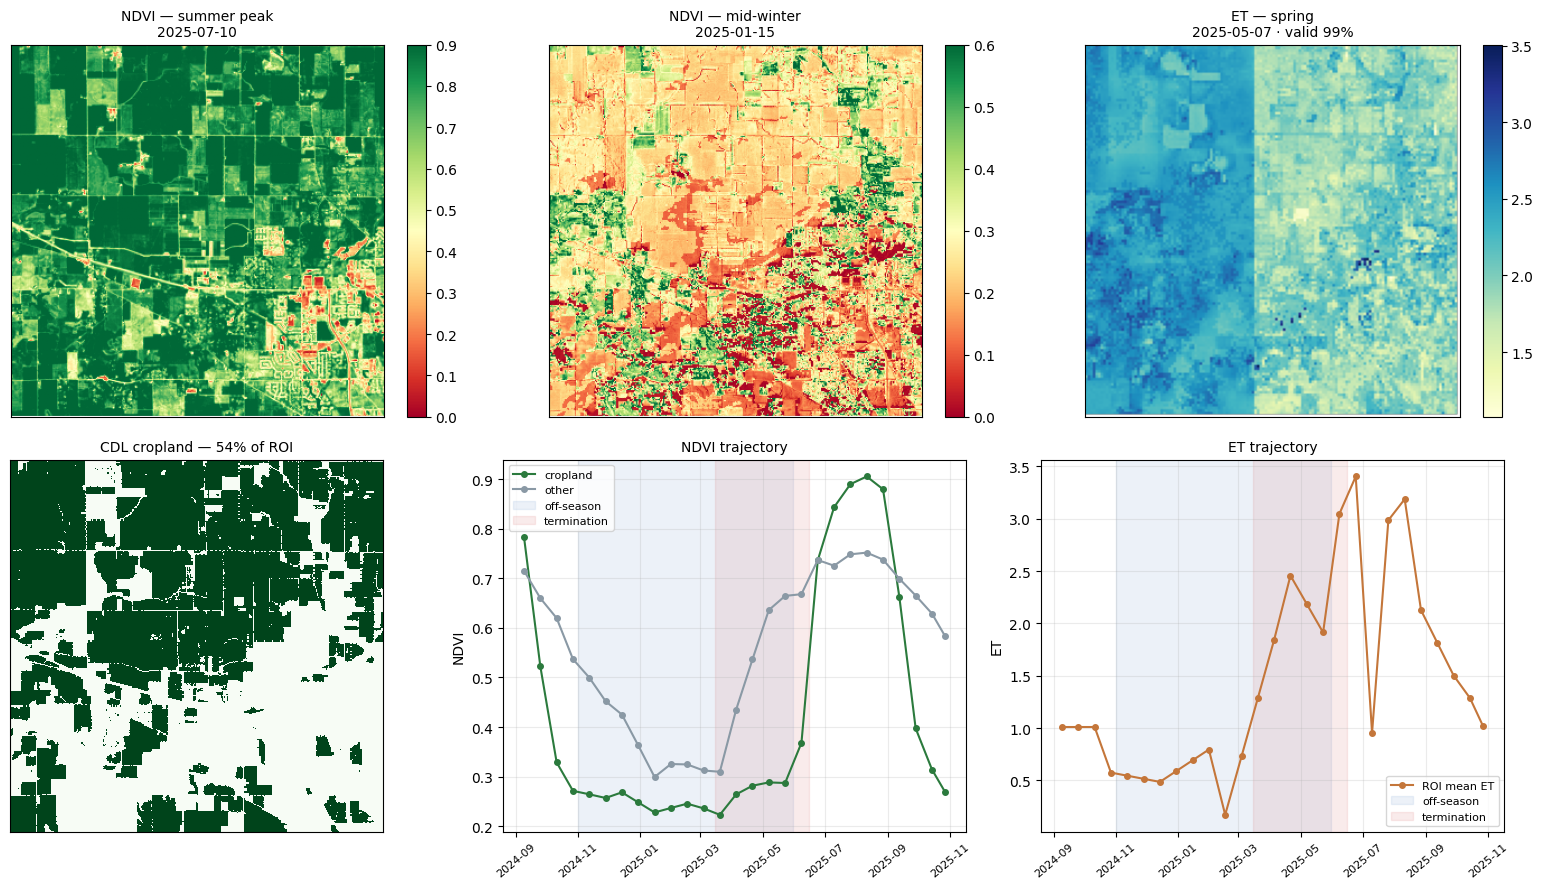

saved: /home/jovyan/fusion_work/figures/fused_cube_qc.png

summer cropland NDVI : 0.843   (expect > 0.7 — lower means the mask or compositing is wrong)
winter cropland NDVI : 0.228   vs non-cropland 0.299
ET spring frame valid: 98.6%   (expect ~100% — a hard-edged void means grid truncation)


In [12]:
# =============================================================================
# Cell 12 — Visual inspection of the fused cube
# =============================================================================
# load() + close: holding the file open would block Cell 10 from rewriting it.
with xr.open_dataset(P("fused_cube.nc")) as _f:
    fused = _f.load()
cdl = rxr.open_rasterio(P("cdl.tif"), masked=False).squeeze(drop=True)
grid30 = load_da(P("grid_30m.nc")).rio.write_crs(
    gpd.read_file(P("roi.geojson")).estimate_utm_crs())

cropland = np.isin(
    cdl.rio.reproject_match(grid30, resampling=Resampling.nearest).values,
    CFG["crop_codes"])

t = pd.DatetimeIndex(fused.time.values)
i_summer = int(np.argmin(np.abs(t - pd.Timestamp("2025-07-15"))))
i_winter = int(np.argmin(np.abs(t - pd.Timestamp("2025-01-15"))))
i_spring = int(np.argmin(np.abs(t - pd.Timestamp("2025-05-01"))))

fig, ax = plt.subplots(2, 3, figsize=(16, 9))

for a, i, ttl, cm, vr in [
        (ax[0,0], i_summer, "NDVI — summer peak", "RdYlGn", (0, 0.9)),
        (ax[0,1], i_winter, "NDVI — mid-winter",  "RdYlGn", (0, 0.6))]:
    im = a.imshow(fused.ndvi.values[i], cmap=cm, vmin=vr[0], vmax=vr[1])
    a.set_title(f"{ttl}\n{t[i]:%Y-%m-%d}", fontsize=10)
    plt.colorbar(im, ax=a, fraction=0.046)

et_img = fused.et.values[i_spring]
im = ax[0,2].imshow(et_img, cmap="YlGnBu")
ax[0,2].set_title(f"ET — spring\n{t[i_spring]:%Y-%m-%d} · "
                  f"valid {np.isfinite(et_img).mean():.0%}", fontsize=10)
plt.colorbar(im, ax=ax[0,2], fraction=0.046)

ax[1,0].imshow(cropland, cmap="Greens", interpolation="nearest")
ax[1,0].set_title(f"CDL cropland — {cropland.mean():.0%} of ROI", fontsize=10)

with np.errstate(all="ignore"):
    crop_ts  = np.nanmean(np.where(cropland, fused.ndvi.values, np.nan), axis=(1,2))
    other_ts = np.nanmean(np.where(~cropland, fused.ndvi.values, np.nan), axis=(1,2))
    et_ts    = np.nanmean(fused.et.values, axis=(1,2))

for a, series, ylab, ttl in [
        (ax[1,1], [(crop_ts, "#2b7a3d", "cropland"),
                   (other_ts, "#8a99a5", "other")], "NDVI", "NDVI trajectory"),
        (ax[1,2], [(et_ts, "#c4763a", "ROI mean ET")], "ET", "ET trajectory")]:
    for y, c, lab in series:
        a.plot(t, y, "o-", ms=4, color=c, label=lab)
    a.axvspan(pd.Timestamp(CFG["offseason"][0]), pd.Timestamp(CFG["offseason"][1]),
              color="#4a7ec4", alpha=0.10, label="off-season")
    a.axvspan(pd.Timestamp(CFG["termination"][0]), pd.Timestamp(CFG["termination"][1]),
              color="#c44", alpha=0.10, label="termination")
    a.set_ylabel(ylab); a.set_title(ttl, fontsize=10)
    a.legend(fontsize=8); a.grid(alpha=0.25)
    a.tick_params(axis="x", rotation=40, labelsize=8)

for a in (ax[0,0], ax[0,1], ax[0,2], ax[1,0]):
    a.set_xticks([]); a.set_yticks([])

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, "fused_cube_qc.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"saved: {fig_path}")
print(f"\nsummer cropland NDVI : {crop_ts[i_summer]:.3f}   "
      f"(expect > 0.7 — lower means the mask or compositing is wrong)")
print(f"winter cropland NDVI : {crop_ts[i_winter]:.3f}   "
      f"vs non-cropland {other_ts[i_winter]:.3f}")
print(f"ET spring frame valid: {np.isfinite(et_img).mean():.1%}   "
      f"(expect ~100% — a hard-edged void means grid truncation)")

## Cell 13 — Archive to the CyVerse Data Store

Copies the deliverables into the Data Store. Everything a later session needs to
reproduce or extend the analysis goes with it: the cube, the ROI, the window
definitions, both grids, the CDL clip, the search indices and the QC figure.

The per-scene caches are deliberately left behind — they are large and fully
reproducible from the indices.

In [13]:
# =============================================================================
# Cell 13 — Copy the deliverables to the CyVerse Data Store
# =============================================================================
DEST = CFG["archive"]
os.makedirs(DEST, exist_ok=True)

PRODUCTS = ["fused_cube.nc", "cdl.tif", "roi.geojson", "windows.csv",
            "grid_30m.nc", "grid_70m.nc", "hls_index.csv", "eco_index.csv",
            "ndvi_scenes.nc"]

# A small manifest so a later session knows what it is looking at
manifest = {"region": CFG["region"], "center": CFG["center"],
            "half_km": CFG["half_km"], "x_days": CFG["x_days"],
            "period": [CFG["date_start"], CFG["date_end"]],
            "eco_product": CFG["eco_product"], "eco_var": CFG["eco_var"],
            "crop_codes": CFG["crop_codes"],
            "created": pd.Timestamp.now().isoformat(timespec="seconds")}
with open(P("manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)
PRODUCTS.append("manifest.json")

copied, missing, total_mb = [], [], 0.0
for name in PRODUCTS:
    src = P(name)
    if not os.path.exists(src):
        missing.append(name); continue
    shutil.copy2(src, os.path.join(DEST, name))
    mb = os.path.getsize(src) / 1e6
    total_mb += mb
    copied.append((name, mb))

fig_src = os.path.join(FIG_DIR, "fused_cube_qc.png")
if os.path.exists(fig_src):
    shutil.copy2(fig_src, os.path.join(DEST, "fused_cube_qc.png"))
    copied.append(("fused_cube_qc.png", os.path.getsize(fig_src) / 1e6))

print(f"archived to {DEST}\n")
for name, mb in copied:
    print(f"  {name:<22} {mb:>8.2f} MB")
print(f"  {'total':<22} {total_mb:>8.2f} MB")
if missing:
    print(f"\nnot found (run the earlier cells): {missing}")

# Confirm from the destination, not from what we think we wrote
present = sorted(os.listdir(DEST))
print(f"\nfiles now in the Data Store folder: {len(present)}")
print("  " + ", ".join(present))

archived to /data-store/iplant/home/pengyuwh/CoverCrop_Fusion

  fused_cube.nc             14.26 MB
  cdl.tif                    0.16 MB
  roi.geojson                0.00 MB
  windows.csv                0.00 MB
  grid_30m.nc                0.46 MB
  grid_70m.nc                0.10 MB
  hls_index.csv              0.14 MB
  eco_index.csv              0.11 MB
  ndvi_scenes.nc            51.62 MB
  manifest.json              0.00 MB
  fused_cube_qc.png          1.50 MB
  total                     66.85 MB

files now in the Data Store folder: 11
  cdl.tif, eco_index.csv, fused_cube.nc, fused_cube_qc.png, grid_30m.nc, grid_70m.nc, hls_index.csv, manifest.json, ndvi_scenes.nc, roi.geojson, windows.csv


---
## Where this leaves

`fused_cube.nc` holds NDVI and ET on one 16-day axis, clipped to the ROI, with
gaps filled and both grids spanning the full study area. It is archived in the
Data Store alongside everything needed to rebuild it.

**Re-running.** Any cell can be run on its own after a kernel restart — each
loads what it needs from disk. Deleting a product file makes the cell that
creates it rebuild; deleting a cache directory makes that download run again.

**Adding LST.** Set `CFG["eco_product"] = "ECO_L2T_LSTE"` and `CFG["eco_var"] =
"LST"`, then re-run Cells 8–10. LST is instantaneous, so it also needs
overpass-time normalisation before values from different days are comparable —
that step is not in this notebook.

**Feeding firerx.** The cube's time steps become individual GeoTIFF layers, since
the firerx config schema has no time dimension. That export is a separate step.

### Two things to carry forward when reading any result

**Winter is when thermal data is weakest.** November to February, cover crops are
dormant and bare soil does not evapotranspire either — ET approaches zero for
both, and differences track soil moisture and snow rather than plant physiology.
ECOSTRESS earns its place in the April–May termination window.

**Part of the cube is interpolated, not measured.** Cell 10 prints the share.
Interpolated ET is not measured ET, and a gap-filled winter NDVI window carries
far less evidence than a clear one.
